# Improved Data Preprocessing
This notebook is an improved version of `01_data_preprocessing.ipynb`.

**Main improvements introduced:**
1. **Data Leakage Resolution**: Splitting into Train and Test is performed *before* scaling and feature selection.
2. **Separate Feature Handling**: Fingerprints and continuous descriptors are handled more cleanly (binary fingerprints do not need RobustScaler).
3. **Documentation**: Added comments and markdown to explain the steps.
4. **Cross Validation**: Improved validation to obtain stronger metrics.

In [1]:
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, AllChem
RDLogger.DisableLog('rdApp.*')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings('ignore')
random_state = 42

## 1. Load Data and Calculate Descriptors

In [2]:
# Load Dataset
df = pd.read_csv('../data/processed/toxicity_dataset_with_descriptors.csv')
print(f"Initial shape: {df.shape}")

# Safe function for descriptors
def safe_desc(func, mol):
    try:
        return func(mol) if mol is not None else np.nan
    except:
        return np.nan

df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)

# Use ALL RDKit descriptors to maximize available features
all_descriptors = {name: func for name, func in Descriptors.descList}

for name, func in all_descriptors.items():
    df[name] = df['mol'].apply(lambda m: safe_desc(func, m))

extra_descriptors = {
    'T.P.S.A.-(Tot)': lambda m: rdMolDescriptors.CalcTPSA(m),
    'S.A.acc.': lambda m: rdMolDescriptors.CalcNumHBA(m),
    'H (050)': lambda m: Descriptors.NumH(m),
    'M-LOG-P': lambda m: Descriptors.MolLogP(m),
    'RDCHI': lambda m: Descriptors.RDChi(m),
    'GAT S1p': lambda m: Descriptors.MolMR(m),
    'N.Nitrogen': lambda m: sum(1 for atom in m.GetAtoms() if atom.GetSymbol() == 'N'),
    'C (040)': lambda m: sum(1 for atom in m.GetAtoms() if atom.GetSymbol() == 'C'),
}

for name, func in extra_descriptors.items():
    df[name] = df['mol'].apply(lambda m: safe_desc(func, m))

# Morgan Fingerprints (512 bit)
df['fp'] = df['mol'].apply(lambda m: list(AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=512)) if m else [0]*512)

# Clean invalid compounds
df = df.dropna(subset=['Y'])

Initial shape: (5170, 14)


## 2. Data Cleaning (Outliers)

Shape after filtering: (5157, 221)


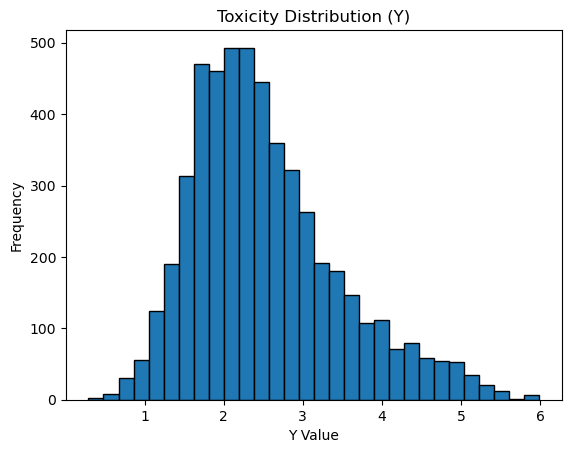

In [ ]:
# Filter on Y values
df = df[(df['Y'] > 0.1) & (df['Y'] < 6)]
print(f"Shape after filtering: {df.shape}")

plt.hist(df['Y'], bins=30, edgecolor='k')
plt.title('LD50 Distribution (lower = more toxic)')
plt.xlabel('LD50 (log scale)')
plt.ylabel('Frequency')
plt.show()

## 3. Train/Test Split (Prevents Data Leakage)
We separate the data *before* performing scaling and feature correlation/selection.

In [4]:
# Prepare X and y
desc_cols = list(all_descriptors.keys())
fp_cols = [f'fp_{i}' for i in range(512)]

# Fill any NaN resulting from RDKit with 0 to prevent crashes
df[desc_cols] = df[desc_cols].fillna(0)

X_desc = df[desc_cols]
X_fp = pd.DataFrame(df['fp'].tolist(), index=df.index, columns=fp_cols)
X = pd.concat([X_desc, X_fp], axis=1)
y = df['Y']

# Data Leakage Prevention: split BEFORE scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# Only continuous descriptors are scaled (binary FP features are not)
scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[desc_cols] = scaler.fit_transform(X_train[desc_cols])
X_test_scaled[desc_cols] = scaler.transform(X_test[desc_cols])

## 4. Feature Selection (based ONLY on Train set)
We remove constant features and use hierarchical clustering to reduce collinear features.

In [5]:
# Remove constant features
non_constant_mask = X_train_scaled.nunique() > 1
X_train_scaled = X_train_scaled.loc[:, non_constant_mask]
X_test_scaled = X_test_scaled.loc[:, non_constant_mask]

# Correlation and clustering (only on TRAIN set)
corr = X_train_scaled.corr().abs()

# Handle any NaN in correlation by replacing them with 0
corr = corr.fillna(0)

Z = linkage(corr, method='ward')
clusters = fcluster(Z, t=0.99, criterion='distance')

cluster_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'cluster': clusters
})

selected_features = cluster_df.groupby('cluster').first()['feature'].tolist()
print(f"Features kept after clustering: {len(selected_features)} out of {X_train_scaled.shape[1]}")

# Apply selection to both train and test
X_train_reduced = X_train_scaled[selected_features]
X_test_reduced = X_test_scaled[selected_features]

Features kept after clustering: 653 out of 715


## 5. Model Training and Evaluation

Starting Hyperparameter Optimization with RandomizedSearchCV...
Best XGBoost Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.9}

R² Train: 0.9926
R² Test: 0.5974
RMSE Test: 0.5957


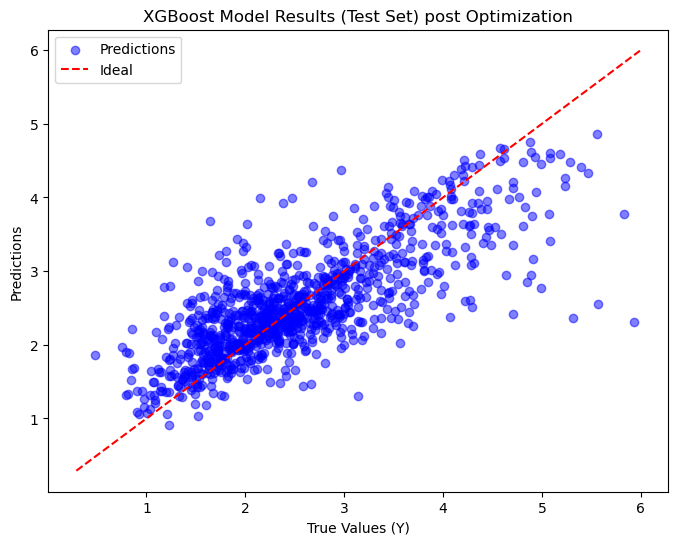

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

print("Starting Hyperparameter Optimization with RandomizedSearchCV...")
param_grid = {
    'n_estimators': [300, 500, 600],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

base_model = XGBRegressor(random_state=random_state)

# n_iter=15 will try about 15 random combinations to speed up execution
random_search = RandomizedSearchCV(
    base_model, param_distributions=param_grid, n_iter=15, 
    scoring='neg_mean_squared_error', cv=5, random_state=random_state, n_jobs=-1
)

random_search.fit(X_train_reduced, y_train)

best_model = random_search.best_estimator_
print(f"Best XGBoost Parameters: {random_search.best_params_}")

y_pred_train = best_model.predict(X_train_reduced)
y_pred_test = best_model.predict(X_test_reduced)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f'\nR² Train: {r2_train:.4f}')
print(f'R² Test: {r2_test:.4f}')
print(f'RMSE Test: {rmse_test:.4f}')

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, color='blue', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Ideal')
plt.xlabel('True LD50 (lower = more toxic)')
plt.ylabel('Predicted LD50')
plt.title('XGBoost Model Results (Test Set) post Optimization')
plt.legend()
plt.show()

In [7]:
# Librerie
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------------------------
# 3. PCA
# ---------------------------
pca = PCA(n_components=5)  # come nel paper, riduzione a 5 componenti principali
X_pca = pca.fit_transform(X_scaled)

# ---------------------------
# 4. Bilanciamento dataset con SMOTE
# ---------------------------
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_pca, y)

# ---------------------------
# 5. Split train/test
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)



ModuleNotFoundError: No module named 'imblearn'